# Part I: Building Monte Carlo Model

Define Model Logic and parameters

In this monte carlo model, we are going to assume a homogeneous atmosphere with a single layer with geometric height of one scale height (~ 8 km). The probability that a photon would travel optical depth $\tau$ without being extinct is derived from the transmittance equation:

$$
P(\tau) = e^{-\tau}
$$

According to this equation, the probability of a photon getting extinct before reaching $\tau$ is defined by the cumulative distribution function as:

$$
\text{CDF}(\tau) = 1 - e^{-\tau}
$$

In order to compute the probability of survival and extinction of a certain number of photons, we will define a $\zeta \sim U(0,1)$ and equal it to the CDF equation above to get the exponential distribution of extinction at each $\tau$. After calculation the $\tau$ for each photon and since our atmosphere is homogeneous and the $\tau$ changes linearly with height, we can use the equation below to calculate the geometric traveled path for each extinct photon:

$$
L = \frac{Z_{atm}}{\mu} \cdot \frac{\tau}{\tau^*}
$$

Additionally, the fraction of photons reaching the surface will be:

$$
t = \frac{N_{\text{surface}}}{N}
$$

I'll define all these parameters with the equations mentioned above in a function, where N, $\tau^*$, $Z_{atm}$, and zenith angle will be assigned as function arguments.

In [122]:
####### Monte Carlo model
import numpy as np
import matplotlib.pyplot as plt


def monte_carlo(N, tau_star, theta_deg, z_atm):
    
    #change the zenith angle to radians and calculate u
    theta_rad = np. radians(theta_deg)
    u = np.cos(theta_rad)
    
    #sanity check to make sure cos(theta_rad) is not below 0
    if u < 0:
        raise ValueError("Theta must be less than 90 degrees.")
    
    #Calculate the analytical linear relationship between optical depth and height, followed by the transmittance 
    z_vals = np.linspace(0, z_atm, 100)
    tau_z = tau_star * (1 - z_vals / z_atm) #for a purely absorbing and homogeneous atmosphere
    t_analytical = np.exp(-tau_z/u)
    #define the uniformly distributed random number between 0 and 1
    zeta = np.random.uniform(0,1,N) #Here we assign a number between 0 and 1 (in this case absorption probability) to each photon
    
    #calculate the optical depth traveled by a photon before extinction 
    tau_traveled = -np.log(1-zeta)
    #now we model the transmitted photons through the atmosphere
    t_model = []
    photons_trans = []
    for tau_level in tau_z:
        photons_trans = np.sum(tau_traveled >= tau_level / u) 
        t_model.append(photons_trans/N)
    t_model = np.array(t_model)
    
    geometric_pathlength = (z_atm * tau_traveled) / (u * tau_star)
    
    #Calculate the needed tau_transmitted to reach surface:
    #If we have a zenith angle, then we have (tau_transmitted)/(tau_star) = (traveled_path)/z_atm, since traveled_path = z_atm/u, we have:
    # (tau_transmitted) = tau_star/u
    tau_transmitted = tau_star / u
    print(f"The required traveled optical depth to reach the surface = {tau_transmitted:.4f}")
    
    #Calculate the number of photons that survive the total depth of atmosphere and reach the surface
    survive = tau_traveled >= tau_transmitted
    N_surface = np.sum(survive)
    print("Number of survived photons to the surface:", N_surface)
    surface_transmittance = N_surface/N
    print(f"Transmitted radiation to the surface based on Monte Carlo = {surface_transmittance:.4f}")
    
    #calculate surface transmittance based on the total optical depth
    t_surface_analytical = np.exp(-tau_transmitted)
    print(f"Transmitted radiation to the surface based on the relation between transmittance and optical depth = {t_surface_analytical:.4f}")
    
    return tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface_analytical, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals
    

# Part II: Model Validation

First Validation

In a purely absorbing atmosphere and with $\tau^*$ = 1 and zenith angle of 0, the transmittance to the surface based on the beer's law will be $t = e^{-\tau^*/\mu}$, which in this case will result in t = 0.3679. This means that near 37% of the incident photons above the atmosphere will make it to the surface. Using the monte carlo model built above, we should be able to calculate a similar t based on the number of surviving photons calculated through the model. As shown below, our model calculation of t is pretty close to the theoretical number. The second and third figures also show the transmittance against the height of atmosphere and optical depth, featuring the correct exponential decay in the transmittance as we go further down into the atmosphere and optical depth increases. If we point to the optical depth of 1, which is the total optical depth of the atmosphere in this case, we'll see that the transmittance points toward around 0.37 ~ 0.38 similar to our calculations. This shows that around 63% of photons were absorbed before reaching optical depth one and 37% of them traveled through this optical depth without being extinct. These figures also show that our model-based calculations match closely with analytical transmittance calculations.

The required traveled optical depth to reach the surface = 1.0000
Number of survived photons to the surface: 36717
Transmitted radiation to the surface based on Monte Carlo = 0.3672
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.3679


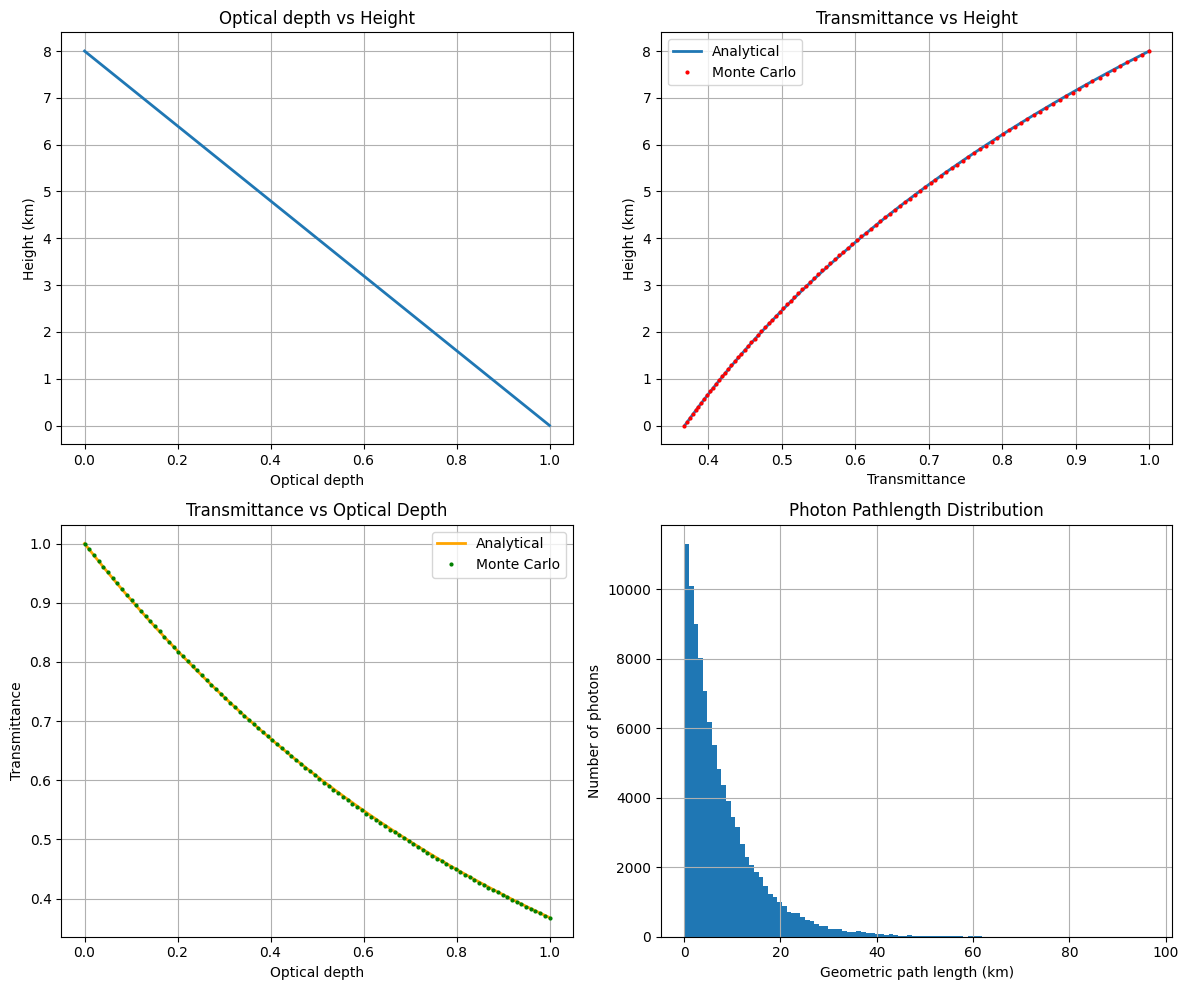

In [123]:
tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(100000, 1, 0, 8)

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# ---- Plot 1: tau vs height ----
axs[0,0].plot(tau_z, z_vals, linewidth=2)
axs[0,0].set_xlabel("Optical depth")
axs[0,0].set_ylabel("Height (km)")
axs[0,0].set_title("Optical depth vs Height")
axs[0,0].grid(True)

# ---- Plot 2: transmittance vs height ----
axs[0,1].plot(t_analytical, z_vals, label="Analytical", linewidth=2)
axs[0,1].plot(t_model, z_vals, 'o', markersize=2, color='red', label="Monte Carlo")
axs[0,1].set_xlabel("Transmittance")
axs[0,1].set_ylabel("Height (km)")
axs[0,1].set_title("Transmittance vs Height")
axs[0,1].legend()
axs[0,1].grid(True)

# ---- Plot 3: transmittance vs tau ----
axs[1,0].plot(tau_z, t_analytical, label="Analytical", linewidth=2, color = 'orange')
axs[1,0].plot(tau_z, t_model, 'o', markersize=2, color = 'green', label="Monte Carlo")
axs[1,0].set_xlabel("Optical depth")
axs[1,0].set_ylabel("Transmittance")
axs[1,0].set_title("Transmittance vs Optical Depth")
axs[1,0].legend()
axs[1,0].grid(True)

# ---- Plot 4: histogram ----
axs[1,1].hist(geometric_pathlength, bins=100)
axs[1,1].set_xlabel("Geometric path length (km)")
axs[1,1].set_ylabel("Number of photons")
axs[1,1].set_title("Photon Pathlength Distribution")
#axs[1,1].legend()
axs[1,1].grid(True)

# adjust spacing
plt.tight_layout()

plt.show()

Second Validation

Now I'll try a very transparent atmosphere, with $\tau^*$ = 0.01. This means that most of our photons should make it to the surface without extinction. The model shows that 99% of our particles reach the surface and the number is equal to what the physical equation of transmittance will yield. The third figure also shows that in comparison with the previous validation, the photons are able to travel much longer paths through this atmosphere.

The required traveled optical depth to reach the surface = 0.0100
Number of survived photons to the surface: 98994
Transmitted radiation to the surface based on Monte Carlo = 0.9899
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.9900


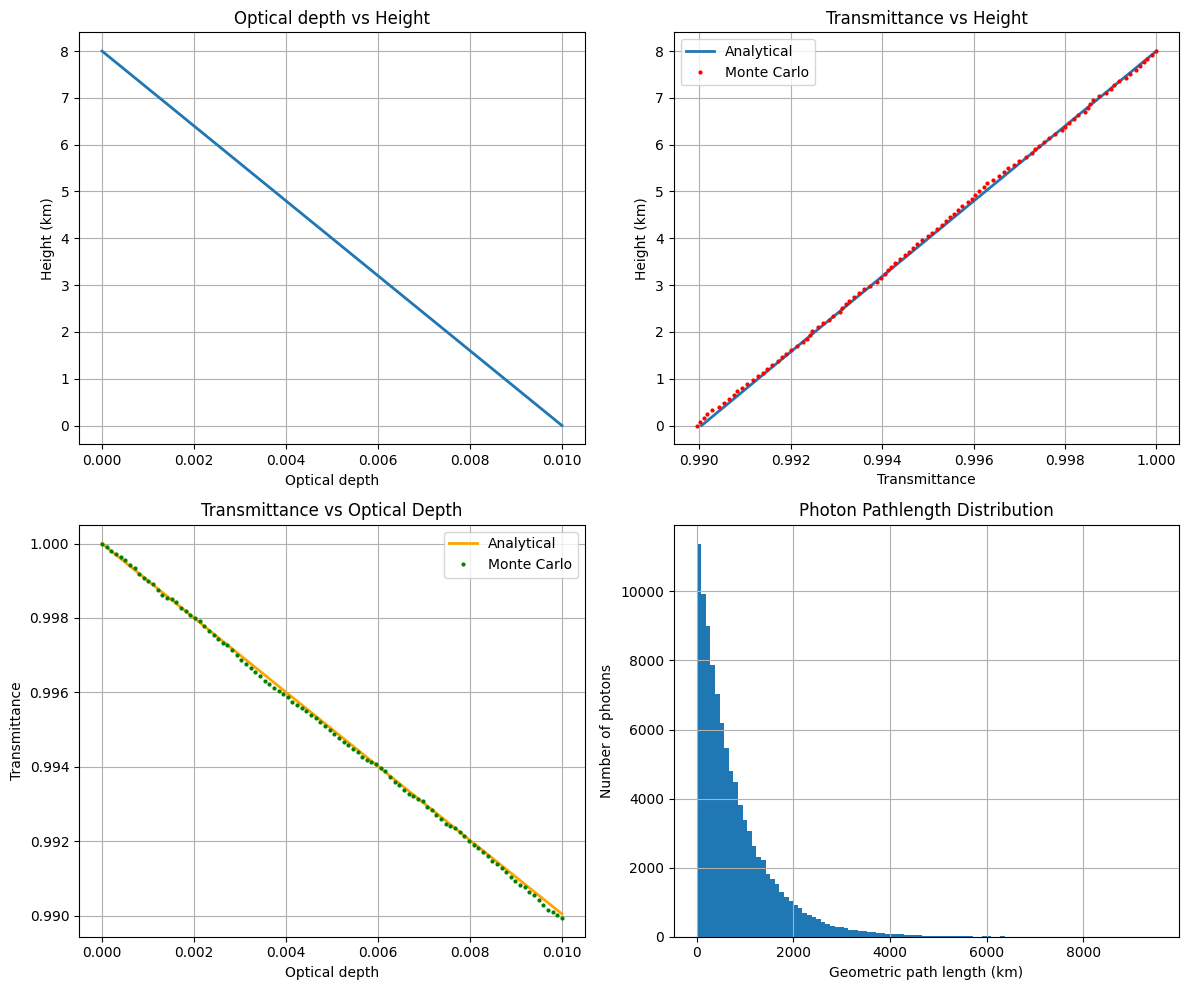

In [124]:
tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals= monte_carlo(100000, 0.01, 0, 8)

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# ---- Plot 1: tau vs height ----
axs[0,0].plot(tau_z, z_vals, linewidth=2)
axs[0,0].set_xlabel("Optical depth")
axs[0,0].set_ylabel("Height (km)")
axs[0,0].set_title("Optical depth vs Height")
axs[0,0].grid(True)

# ---- Plot 2: transmittance vs height ----
axs[0,1].plot(t_analytical, z_vals, label="Analytical", linewidth=2)
axs[0,1].plot(t_model, z_vals, 'o', markersize=2, color='red', label="Monte Carlo")
axs[0,1].set_xlabel("Transmittance")
axs[0,1].set_ylabel("Height (km)")
axs[0,1].set_title("Transmittance vs Height")
axs[0,1].legend()
axs[0,1].grid(True)

# ---- Plot 3: transmittance vs tau ----
axs[1,0].plot(tau_z, t_analytical, label="Analytical", linewidth=2, color = 'orange')
axs[1,0].plot(tau_z, t_model, 'o', markersize=2, color = 'green', label="Monte Carlo")
axs[1,0].set_xlabel("Optical depth")
axs[1,0].set_ylabel("Transmittance")
axs[1,0].set_title("Transmittance vs Optical Depth")
axs[1,0].legend()
axs[1,0].grid(True)

# ---- Plot 4: histogram ----
axs[1,1].hist(geometric_pathlength, bins=100)
axs[1,1].set_xlabel("Geometric path length (km)")
axs[1,1].set_ylabel("Number of photons")
axs[1,1].set_title("Photon Pathlength Distribution")
#axs[1,1].legend()
axs[1,1].grid(True)

# adjust spacing
plt.tight_layout()

plt.show()

Third Validation

Now I'll try a the same atmosphere with $\tau^*$ = 1, but this time the zenith angle will be 90 degrees. In this scenario, we should see almost no photons reaching to the surface and transmittance near zero since the photons are going to travel through a parallel path to the surface at the top of the atmosphere. As shown below, the number of surviving photons is 0 and the model and the physical equation are showing similar transmittance number of 0. 

The required traveled optical depth to reach the surface = 16331239353195370.0000
Number of survived photons to the surface: 0
Transmitted radiation to the surface based on Monte Carlo = 0.0000
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.0000


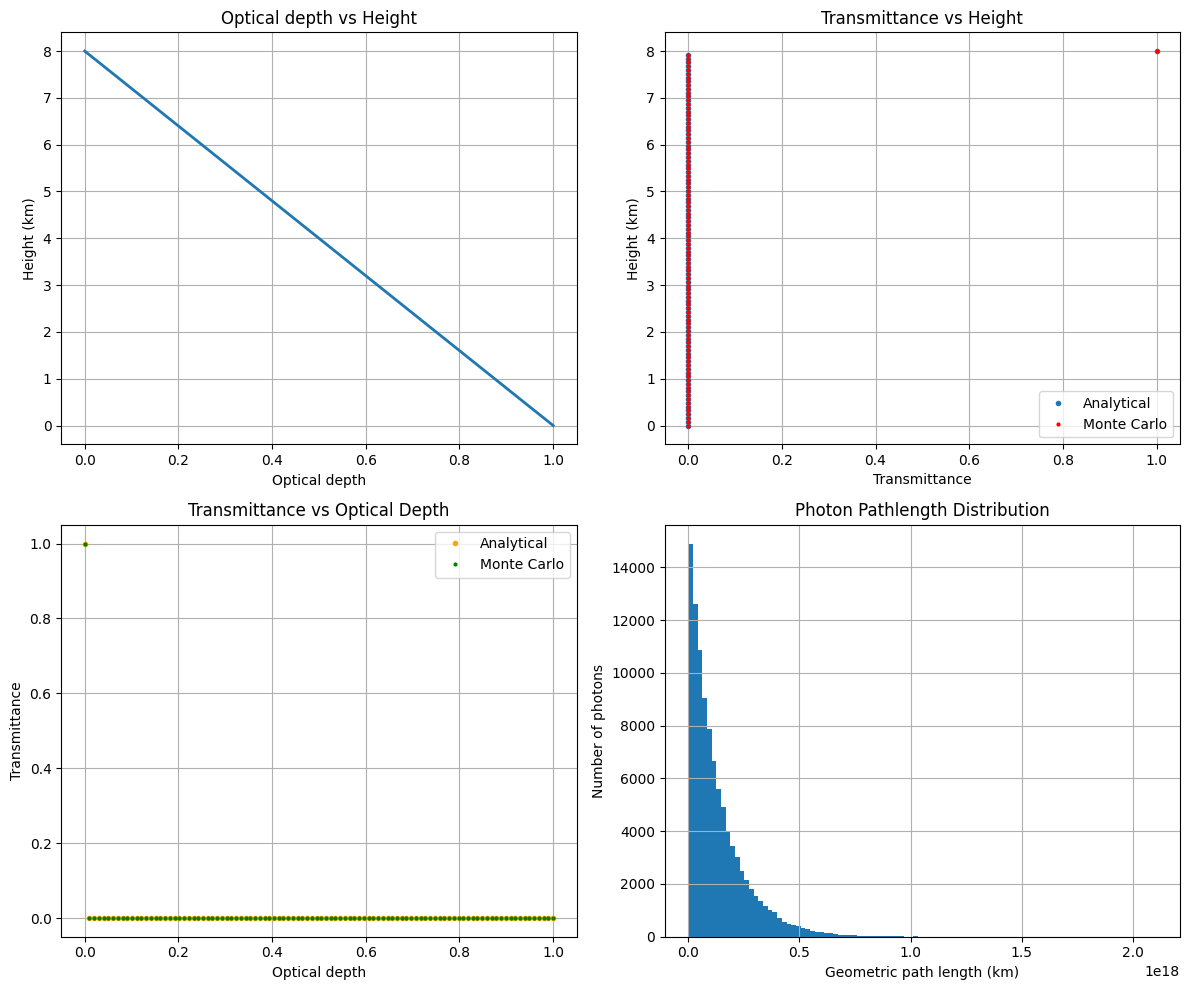

In [125]:
tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(100000, 1, 90, 8)

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# ---- Plot 1: tau vs height ----
axs[0,0].plot(tau_z, z_vals, linewidth=2)
axs[0,0].set_xlabel("Optical depth")
axs[0,0].set_ylabel("Height (km)")
axs[0,0].set_title("Optical depth vs Height")
axs[0,0].grid(True)

# ---- Plot 2: transmittance vs height ----
axs[0,1].plot(t_analytical, z_vals,'o', markersize=3, label="Analytical")
axs[0,1].plot(t_model, z_vals, 'o', markersize=2, color='red', label="Monte Carlo")
axs[0,1].set_xlabel("Transmittance")
axs[0,1].set_ylabel("Height (km)")
axs[0,1].set_title("Transmittance vs Height")
axs[0,1].legend()
axs[0,1].grid(True)

# ---- Plot 3: transmittance vs tau ----
axs[1,0].plot(tau_z, t_analytical, 'o', markersize=3,label="Analytical", color = 'orange')
axs[1,0].plot(tau_z, t_model, 'o', markersize=2, color = 'green', label="Monte Carlo")
axs[1,0].set_xlabel("Optical depth")
axs[1,0].set_ylabel("Transmittance")
axs[1,0].set_title("Transmittance vs Optical Depth")
axs[1,0].legend()
axs[1,0].grid(True)

# ---- Plot 4: histogram ----
axs[1,1].hist(geometric_pathlength, bins=100)
axs[1,1].set_xlabel("Geometric path length (km)")
axs[1,1].set_ylabel("Number of photons")
axs[1,1].set_title("Photon Pathlength Distribution")
#axs[1,1].legend()
axs[1,1].grid(True)

# adjust spacing
plt.tight_layout()

plt.show()

# Part III: Radiative Transfer Experiments

# Question 1

Analytical calculation

For a zenith angle of 0, the transmittance equation turns into:
$$
t = e^{-\tau}
$$
An e-folding reduction in the surface intensity means that the intensity that reaches the surface should be 1/e of the intensity at the top of the atmosphere:
$$
t = \frac{I_{\text{surface}}}{I} = \frac{1}{e} = e^{-\tau}
$$
This results in:
$$
e^{-\tau} = e^{-1} ==> \tau = 1
$$
So for a reduction of e-folding in surface intensity, our atmosphere needs to have and optical depth of 1.

Model simulation:

I have chosen 100000 photons to enter my atmosphere with zenith angle of 0. Since my analytical calculations showed a total optical depth of 1 for the atmosphere, I'll set $\tau^{*}$ to 1 as an input. The results show that the transmittance of photons to the surface shows the same reduction as we calculated based on analytical equations.

In [126]:
tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(100000, 1, 0, 8)

The required traveled optical depth to reach the surface = 1.0000
Number of survived photons to the surface: 36789
Transmitted radiation to the surface based on Monte Carlo = 0.3679
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.3679


# Question 2

Analytical answer:

With optical depth of 1 and zenith angle of 60 degrees we have:
$$
t = e^\frac{-\tau}{\mu} = e^\frac{-1}{\cos(60)} = e^{-2}
$$
So with the same optical depth as the zenith angle increases from 0 to 60, the light travel path through atmosphere increases and thus the transmittance to the surface decreases by and e-folding compared to question 1.

Model simulation:

Using N = 100000 and zenith angle of 60 degrees and $\tau^{*}$ = 1, the model yields a similar transmittance number to the analytical calculations.

In [127]:
tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals= monte_carlo(100000, 1, 60, 8)

The required traveled optical depth to reach the surface = 2.0000
Number of survived photons to the surface: 13521
Transmitted radiation to the surface based on Monte Carlo = 0.1352
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.1353


# Question 3

Analytical answer:

With a solar zenith angle of 90 degrees:
$$
t = e^\frac{-\tau}{\mu} = e^\frac{-\tau}{\cos(90)} = e^\frac{-\tau}{0} = e^{-\infty} = 0
$$
When the sun is at the horizon, the direct solar beam travels an extremely long path through the atmosphere. In a purely absorbing atmosphere, photons can only be removed from the beam; they are not scattered into new directions. Since the path length becomes effectively infinite, essentially all photons are absorbed before reaching the ground. Therefore, the direct beam at the surface goes to zero, so the surface would be dark. 

Model simulation:

The model simulation for this is also shown in the third validation I presented for part II.


# Question 4

Analytical answer:

In a homogeneous atmosphere, the optical depth changes linearly with respect to height. This means that if we have the top of atmosphere and the surface with optical depths and heights of 0, $z_{atm}$ and $\tau^*$, 0, respectively, we can calculate the linear relationship for optical depth and height:
$$
\tau(z) = \tau^* \left(1 - \frac{z}{Z_{atm}}\right)
$$
We can plug this in the transmittance equation:
$$
t(z) = \exp\left[-\tau^* \left(1 - \frac{z}{Z_{atm}}\right)\right]
$$
This shows that as we go down through the atmosphere (z -> 0), the transmittance decreases. If we also increase the $\tau^*$, it would result in a decrease in transmittance through the same height across different optical depths, , and because of the exponential relationship it will drop faster through the first layers at the top of the atmosphere. Considering the amount of light reaching the surface in different scenarios, we have:

$\tau = 1$:
$$
t(0) = e^{-1} = 0.368
$$
$\tau = 3$:
$$
t(0) = e^{-3} = 0.0498
$$
$\tau = 10$:
$$
t(0) = e^{-10} = 4.54 * 10^{-5}
$$
This shows that as optical depth increases, the atmosphere gets more opaque and the light survives less to the surface.

Model simulation:

I've plotted the change in transmittance as a function of height for the three optical depths we have in this question. As shown in the figures below, the transmittance tend to suddenly drop as we go down from top of the atmosphere in a scenario with optical depth of 10, and is almost zero at the surface. The drop becomes smoother as the optical depth decreases to 3 and 1 and more light reaches the surface.


The required traveled optical depth to reach the surface = 1.0000
Number of survived photons to the surface: 36949
Transmitted radiation to the surface based on Monte Carlo = 0.3695
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.3679
The required traveled optical depth to reach the surface = 3.0000
Number of survived photons to the surface: 5000
Transmitted radiation to the surface based on Monte Carlo = 0.0500
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.0498
The required traveled optical depth to reach the surface = 10.0000
Number of survived photons to the surface: 6
Transmitted radiation to the surface based on Monte Carlo = 0.0001
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.0000


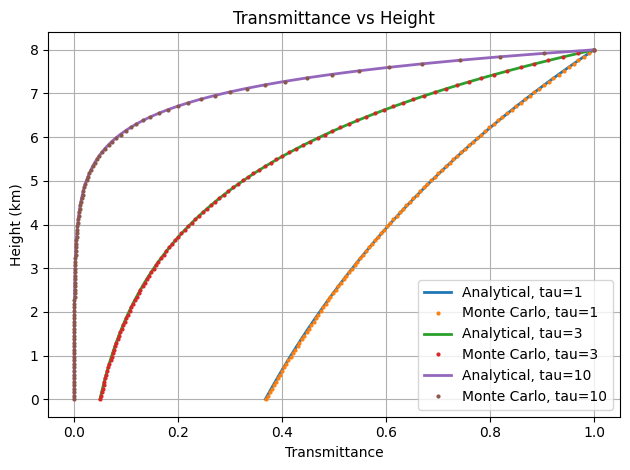

In [128]:
tau_values = [1, 3, 10]

figure = (12, 5)

for tau_star in tau_values:
    tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(
        100000, tau_star, 0, 8
    )

    # Plot 1: transmittance vs height
    plt.plot(t_analytical, z_vals, linewidth=2, label=f"Analytical, tau={tau_star}")
    plt.plot(t_model, z_vals, 'o', markersize=2, label=f"Monte Carlo, tau={tau_star}")


# Formatting for subplot 1
plt.xlabel("Transmittance")
plt.ylabel("Height (km)")
plt.title("Transmittance vs Height")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Part IV: AERONET Observations

# Question 5

For this part, I chose the AERONET Salton Sea site and downloaded the data for September 2020, when there seems to be dust activity in the region between September 12 to 14. The main source of high load of aerosols in this region could be attributed to high speed winds that can kick up dust from the deserts surrounding the Salton Sea. The event appears to start on September 12, but since the change in AOD 500 nm is more visible in the data from September 13, I plotted the trend of AOD 500 and solar zenith angle for this day.

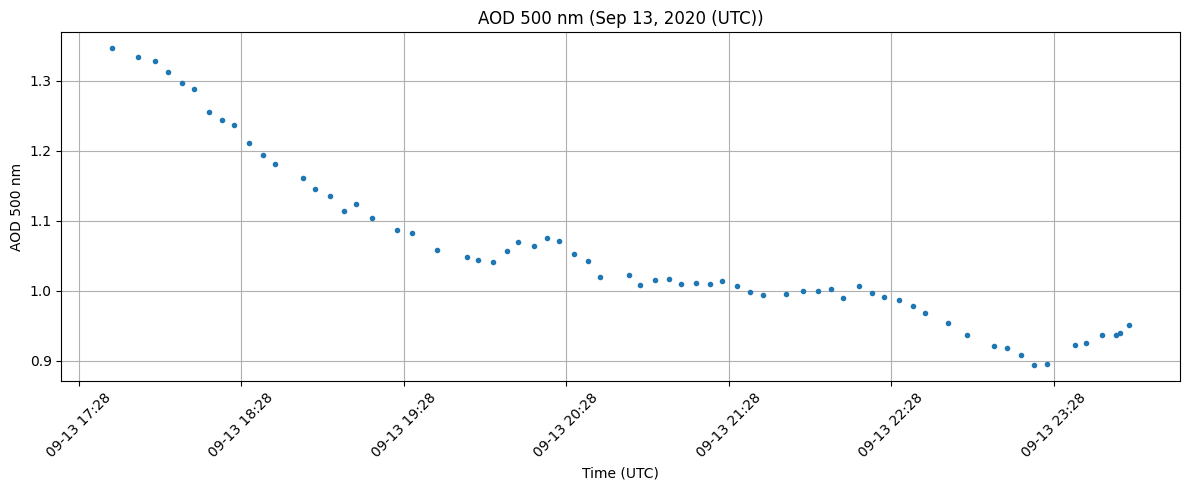

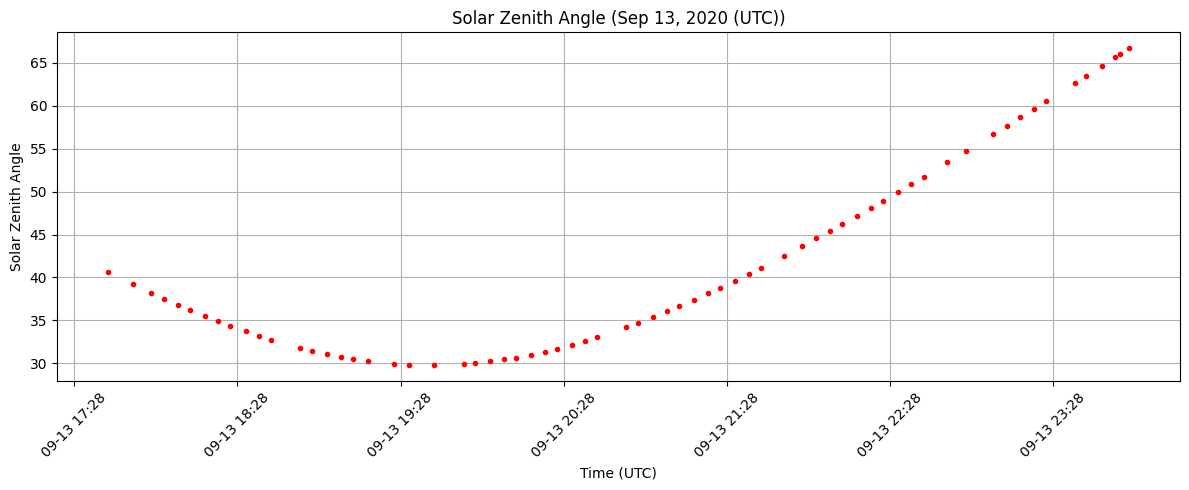

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file = "20200901_20200930_Salton_Sea.lev20"

# read file
df = pd.read_csv(file, skiprows=6)

# clean AOD 500 and save in aod_500
aod_500 = df["AOD_500nm"].replace(-999, np.nan).astype(float)

# optional: keep SZA too
sza = pd.to_numeric(df["Solar_Zenith_Angle(Degrees)"].replace(-999, np.nan), errors="coerce")

# combine date + time and keep as UTC
df["datetime_utc"] = pd.to_datetime(
    df["Date(dd:mm:yyyy)"] + " " + df["Time(hh:mm:ss)"],
    format="%d:%m:%Y %H:%M:%S",
    errors="coerce",
    utc=True
)
time_utc = df["datetime_utc"]
# define UTC time window
start = pd.Timestamp("2020-09-13 00:00:00", tz="UTC")
end   = pd.Timestamp("2020-09-13 23:59:59", tz="UTC")

# apply same mask to both time and AOD
mask = (df["datetime_utc"] >= start) & (df["datetime_utc"] <= end)

time_subset = df.loc[mask, "datetime_utc"]
aod_500_subset = aod_500.loc[mask]
sza_subset = sza.loc[mask]

# plot
plt.figure(figsize=(12, 5))
plt.plot(time_subset, aod_500_subset, 'o', markersize = 3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
plt.xticks(rotation=45)

plt.xlabel("Time (UTC)")
plt.ylabel("AOD 500 nm")
plt.title("AOD 500 nm (Sep 13, 2020 (UTC))")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(time_subset, sza_subset, 'o', markersize=3, color = 'red')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
plt.xticks(rotation=45)

plt.xlabel("Time (UTC)")
plt.ylabel("Solar Zenith Angle")
plt.title("Solar Zenith Angle (Sep 13, 2020 (UTC))")
plt.grid(True)
plt.tight_layout()
plt.show()

• How does the direct transmittance at the surface change throughout the day?

At the start of the day with the first available data (17:40 UTC), we have optical depth of 1.34 and zenith angle of 40.6 degrees, which indicates morning time around 9 am. The surface transmittance would be t = 0.1696. As we move toward noon (20:00 UTC), the zenith angle decreases and also the optical depth in this day start to go down, so we should be able to see higher transmittance. With optical depth of 1.04 and zenith angle of 30.2, t = 0.299, which is the highest level throughout the day. Right after this point, there is a dip in surface t at 20:30 UTC. This dip correspond closely to the and increase in AOD during the same period, which points toward the affect of AOD on surface t with little variation in zenith angle. Moving toward afternoon and night, the optical depth keeps decreasing, while the zenith angle starts to increase. Despite the decrease in AOD, the increased zenith angle causes the surface t to drop down to t = 0.09 at 23:55 UTC, with optical depth of 0.95 and zenith angle of 66.7.

The required traveled optical depth to reach the surface = 1.7745
Number of survived photons to the surface: 16772
Transmitted radiation to the surface based on Monte Carlo = 0.1677
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.1696
The required traveled optical depth to reach the surface = 1.7216
Number of survived photons to the surface: 17913
Transmitted radiation to the surface based on Monte Carlo = 0.1791
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.1788
The required traveled optical depth to reach the surface = 1.6914
Number of survived photons to the surface: 18540
Transmitted radiation to the surface based on Monte Carlo = 0.1854
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.1843
The required traveled optical depth to reach the surface = 1.6546
Number of survived photons to the surface: 19128
Transmitted rad

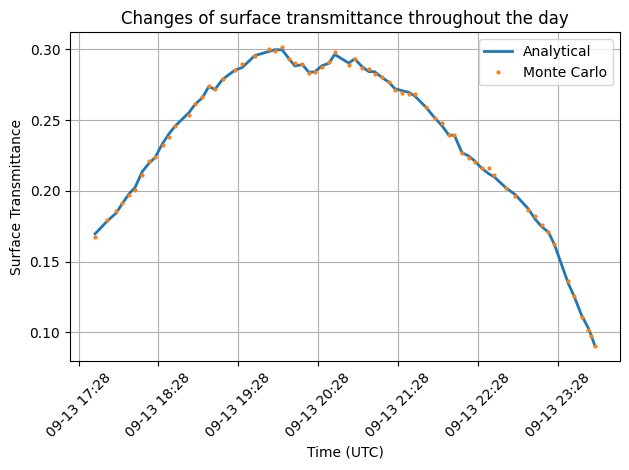

In [130]:
tau_values = aod_500_subset.tolist()
zenith_angles = sza_subset.tolist()
tau_theta_pairs = list(zip(tau_values, zenith_angles))
Salton_sea_t_surface_analytical = []
Salton_sea_t_surface_model = []
figure = (12, 5)

for tau_star, theta_deg in zip(tau_values, zenith_angles):
    tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(
        100000, tau_star, theta_deg, 8
    )
    Salton_sea_t_surface_analytical.append(t_surface)
    Salton_sea_t_surface_model.append(surface_transmittance)

 # Plot 1: transmittance vs height
plt.plot(time_subset, Salton_sea_t_surface_analytical, linewidth=2, label=f"Analytical")
plt.plot(time_subset, Salton_sea_t_surface_model, 'o', markersize=2, label=f"Monte Carlo")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
plt.xticks(rotation=45)

# Formatting for subplot 1
plt.xlabel("Time (UTC)")
plt.ylabel("Surface Transmittance")
plt.title("Changes of surface transmittance throughout the day")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()   



• For a constant τ , which should be the daily mean value, how does the direct surface transmittance change throughout the day?

With a constant optical depth, the surface transmittance will follow the changes in the solar zenith angle, with the peak surface t of near 0.3 at 20:00 UTC (noon local), and a continuous decrease as the sun moves toward the horizon.

The required traveled optical depth to reach the surface = 1.3943
Number of survived photons to the surface: 24933
Transmitted radiation to the surface based on Monte Carlo = 0.2493
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.2480
The required traveled optical depth to reach the surface = 1.3651
Number of survived photons to the surface: 25489
Transmitted radiation to the surface based on Monte Carlo = 0.2549
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.2553
The required traveled optical depth to reach the surface = 1.3467
Number of survived photons to the surface: 25876
Transmitted radiation to the surface based on Monte Carlo = 0.2588
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.2601
The required traveled optical depth to reach the surface = 1.3342
Number of survived photons to the surface: 26244
Transmitted rad

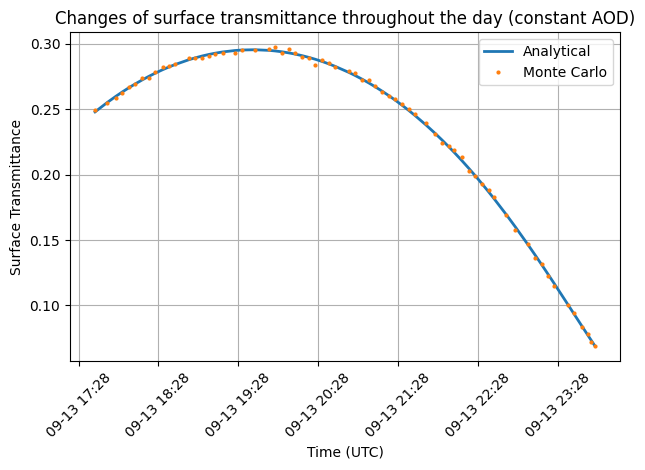

In [131]:
tau_values = aod_500_subset.tolist()
tau = np.mean(tau_values)
zenith_angles = sza_subset.tolist()
Salton_sea_t_surface_analytical = []
Salton_sea_t_surface_model = []
figure = (12, 5)

for theta_deg in zenith_angles:
    tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(
        100000, tau, theta_deg, 8
    )
    Salton_sea_t_surface_analytical.append(t_surface)
    Salton_sea_t_surface_model.append(surface_transmittance)

 # Plot 1: transmittance vs height
plt.plot(time_subset, Salton_sea_t_surface_analytical, linewidth=2, label=f"Analytical")
plt.plot(time_subset, Salton_sea_t_surface_model, 'o', markersize=2, label=f"Monte Carlo")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
plt.xticks(rotation=45)

# Formatting for subplot 1
plt.xlabel("Time (UTC)")
plt.ylabel("Surface Transmittance")
plt.title("Changes of surface transmittance throughout the day (constant AOD)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()   



• For a constant θ, which should be the day’s maximum value, how does the direct surface transmittance change throughout the day?

In this case, the surface t follows the changes in optical depth of the atmosphere during the day. According to the AOD 500 nm timeseries, the peak AOD is in the morning (17:00 UTC). As a result, we'll observe the lowest surface t level during this time (t = 0.032). As we move through the day and the AOD declines, the surface t increases until in reaches its max at t = 0.104 (23:28 UTC). The decline after this point in the curve corresponds to the increase in AOD values after 23:28 UTC.

The required traveled optical depth to reach the surface = 3.4039
Number of survived photons to the surface: 3296
Transmitted radiation to the surface based on Monte Carlo = 0.0330
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.0332
The required traveled optical depth to reach the surface = 3.3731
Number of survived photons to the surface: 3344
Transmitted radiation to the surface based on Monte Carlo = 0.0334
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.0343
The required traveled optical depth to reach the surface = 3.3592
Number of survived photons to the surface: 3455
Transmitted radiation to the surface based on Monte Carlo = 0.0345
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.0348
The required traveled optical depth to reach the surface = 3.3171
Number of survived photons to the surface: 3723
Transmitted radiati

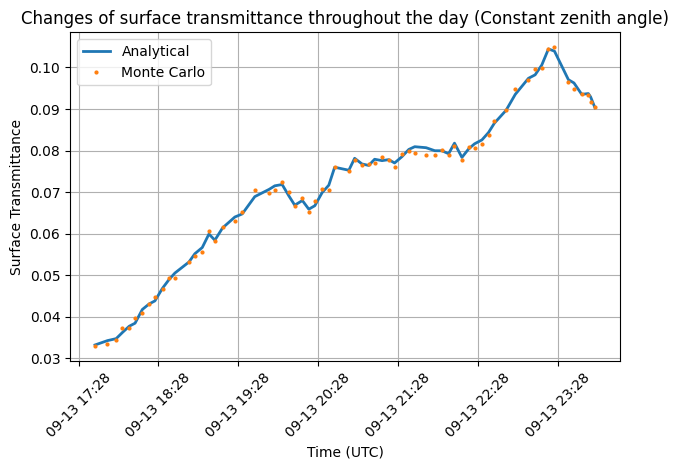

In [132]:
tau_values = aod_500_subset.tolist()
zenith_angles = sza_subset.tolist()
theta = np.max(zenith_angles)
Salton_sea_t_surface_analytical = []
Salton_sea_t_surface_model = []
figure = (12, 5)

for tau in tau_values:
    tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(
        100000, tau, theta, 8
    )
    Salton_sea_t_surface_analytical.append(t_surface)
    Salton_sea_t_surface_model.append(surface_transmittance)

 # Plot 1: transmittance vs height
plt.plot(time_subset, Salton_sea_t_surface_analytical, linewidth=2, label=f"Analytical")
plt.plot(time_subset, Salton_sea_t_surface_model, 'o', markersize=2, label=f"Monte Carlo")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
plt.xticks(rotation=45)

# Formatting for subplot 1
plt.xlabel("Time (UTC)")
plt.ylabel("Surface Transmittance")
plt.title("Changes of surface transmittance throughout the day (Constant zenith angle)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()   



• What factor is most responsible for the estimated changes in transmittance at the surface, τ or θ?

In the context of the selected day and event, the solar zenith angle is more responsible for changes in surface transmittance. This can be inferred from the previous two questions, in which AOD and zenith angle were constant through the day, respectively. The changes in optical depth with constant zenith angle results in $\Delta t \approx 0.07$, while changes in zenith angle with results a $\Delta t \approx 0.2$.

# Part V: Student Investigation

In part III, we saw how the transmittance through the height of the atmosphere changes with optical depth. The plot showed that at higher AODs, the transmittance curve drops more drastically at the first layers of the atmosphere. Here for the first investigation, my question is that how does the transmittance vary with the height if we have different solar zenith angles with an atmosphere with $\tau = 1$? As the model and the analytical calculations show below, the behavior of transmittance variation with height is similar to what we observed in part III. Here, as the solar zenith angle increases, the path length that the photons need to travel through at certain height intervals increases, which results in a drastic absorption near the top of thr atmosphere.

The required traveled optical depth to reach the surface = 1.0000
Number of survived photons to the surface: 37124
Transmitted radiation to the surface based on Monte Carlo = 0.3712
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.3679
The required traveled optical depth to reach the surface = 1.0353
Number of survived photons to the surface: 35304
Transmitted radiation to the surface based on Monte Carlo = 0.3530
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.3551
The required traveled optical depth to reach the surface = 1.1547
Number of survived photons to the surface: 31511
Transmitted radiation to the surface based on Monte Carlo = 0.3151
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.3152
The required traveled optical depth to reach the surface = 1.4142
Number of survived photons to the surface: 24228
Transmitted rad

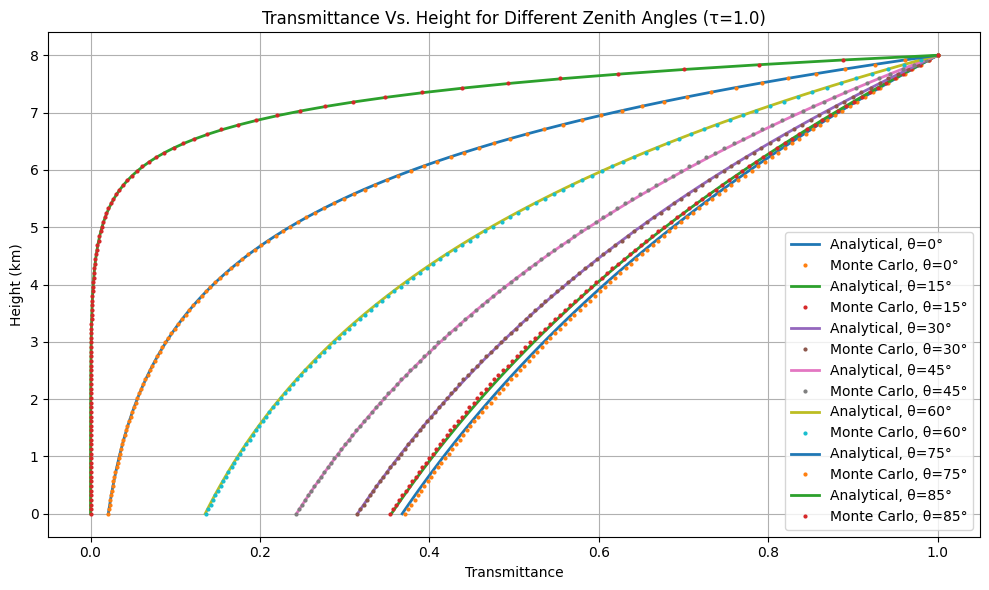

In [133]:
import numpy as np
import matplotlib.pyplot as plt

tau_star = 1.0
z_atm = 8
theta_values = [0 , 15, 30, 45, 60, 75, 85]

plt.figure(figsize=(10, 6))

for theta_deg in theta_values:
    tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(
        100000, tau_star, theta_deg, z_atm
    )
    
    plt.plot(t_analytical, z_vals, linewidth=2, label=f"Analytical, θ={theta_deg}°")
    plt.plot(t_model, z_vals, 'o', markersize=2, label=f"Monte Carlo, θ={theta_deg}°")

plt.xlabel("Transmittance")
plt.ylabel("Height (km)")
plt.title(f"Transmittance Vs. Height for Different Zenith Angles (τ={tau_star})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

For the second investigation, my hypothesis is that as the optical depth increases to numbers >1, the dependence of surface transmittance to solar zenith angle will decrease and the changes in surface t throughout a day will become smaller. To test this hypothesis, I define an interval between 0 to 85 degrees for my daily variation of zenith angle and 4 different optical depth scenarios. Next, I will calculate the changes in the surface transmittance for each optical depth case with respect to changes in the zenith angle. The analytical and model results confirm my initial hypothesis, showing that as the optical depth increases toward 5, the surface t variation decreases. This shows that in an atmosphere with heavy aerosol loading, the solar zenith angle influence on surface t variation becomes less effective compared to optical depth.

The required traveled optical depth to reach the surface = 0.1000
Number of survived photons to the surface: 90429
Transmitted radiation to the surface based on Monte Carlo = 0.9043
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.9048
The required traveled optical depth to reach the surface = 0.1000
Number of survived photons to the surface: 90508
Transmitted radiation to the surface based on Monte Carlo = 0.9051
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.9048
The required traveled optical depth to reach the surface = 0.1000
Number of survived photons to the surface: 90439
Transmitted radiation to the surface based on Monte Carlo = 0.9044
Transmitted radiation to the surface based on the relation between transmittance and optical depth = 0.9048
The required traveled optical depth to reach the surface = 0.1001
Number of survived photons to the surface: 90508
Transmitted rad

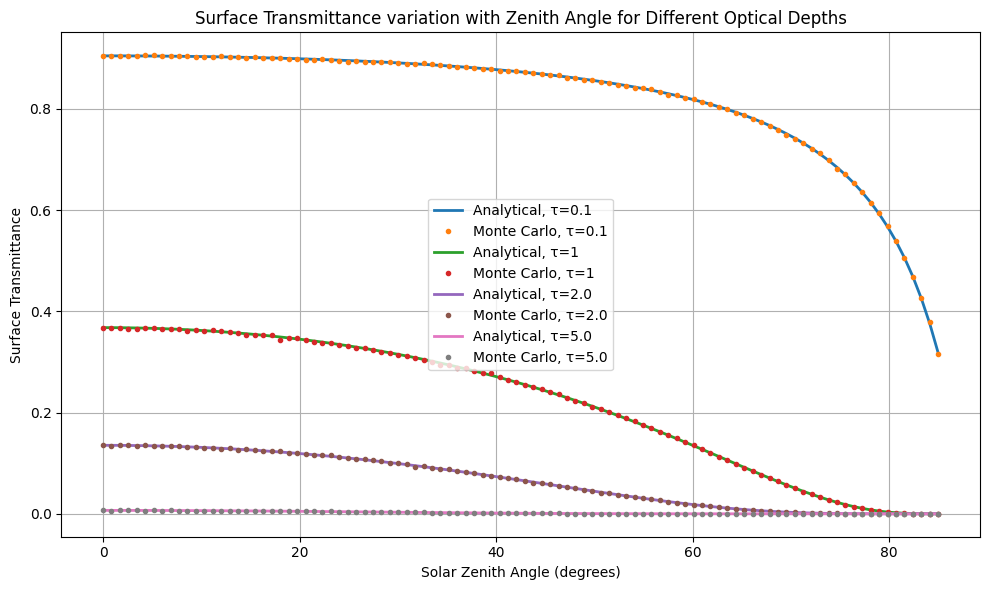

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# zenith angle range for the experiment
zenith_angles = np.linspace(0, 85, 100)  

# choose fixed optical depths to compare
tau_values = [0.1, 1,  2.0, 5.0]

analytical_results = {}
model_results = {}

for tau_star in tau_values:
    t_surface_analytical = []
    t_surface_model = []
    
    for theta_deg in zenith_angles:
        tau_traveled, tau_transmitted, N_surface, surface_transmittance, t_surface, survive, geometric_pathlength, tau_z, t_analytical, t_model, z_vals = monte_carlo(
            100000, tau_star, theta_deg, 8
        )
        
        t_surface_analytical.append(t_surface)
        t_surface_model.append(surface_transmittance)
    
    analytical_results[tau_star] = t_surface_analytical
    model_results[tau_star] = t_surface_model

# Plot
plt.figure(figsize=(10, 6))

for tau_star in tau_values:
    plt.plot(
        zenith_angles,
        analytical_results[tau_star],
        linewidth=2,
        label=f"Analytical, τ={tau_star}"
    )
    plt.plot(
        zenith_angles,
        model_results[tau_star],
        'o',
        markersize=3,
        label=f"Monte Carlo, τ={tau_star}"
    )

plt.xlabel("Solar Zenith Angle (degrees)")
plt.ylabel("Surface Transmittance")
plt.title("Surface Transmittance variation with Zenith Angle for Different Optical Depths")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# AI usage

AI tool: ChatGPT

Usage:

1. Write down equations and symbols in markdown format.
2. How to use the uniformly distributed number between 0 to 1 to assign a random fate to each one of the photons.
3. In the main model logic, AI was used to help with the loop to create the modeled transmittance across the atmosphere height.
3. Perform the plotting sections for validation, part III, IV, and V.
4. Write the code to read and extract data from AERONET dataset.
